# Riad Vente - Marrakech
Cleaning + Training + Evaluation

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../../pipeline/ventes"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json, joblib
from datetime import datetime
from pathlib import Path
from pip_riad import (
    load_data, split_and_encode, build_pipeline, train,
    evaluate, plot_results, predict_price, tune_hyperparams,
    NUMERIC_FEATURES, BINARY_FEATURES, CATEGORICAL_FEATURES, TARGET_LOG
)

RAW_PATH   = Path("../../data/marrakech_immo_vente/riad_vente.csv")
MODEL_PATH = Path("../../model_training/models/xgb_riad_vente.pkl")
META_PATH  = Path("../../model_training/models/xgb_riad_vente_metadata.json")
CLEAN_PATH = Path("../../data/cleaned_data/vente/riad_vente_final.csv")
print("Imports OK")

/home/nouhayla/Desktop/stage/gateone-deploy/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Imports OK


## 1. Chargement et Cleaning

In [2]:
df = load_data(RAW_PATH)
print(f"Dataset final : {len(df)} riads | {df['zone_clean'].nunique()} zones")

 Chargement : 1594 lignes, 34 colonnes
   Riads : 709
   Après filtres : 468 lignes
   Prix médian    : 3,500,000 MAD
   Surface médiane: 160 m²
   pm² médian     : 21,761 MAD/m²
Dataset final : 468 riads | 5 zones


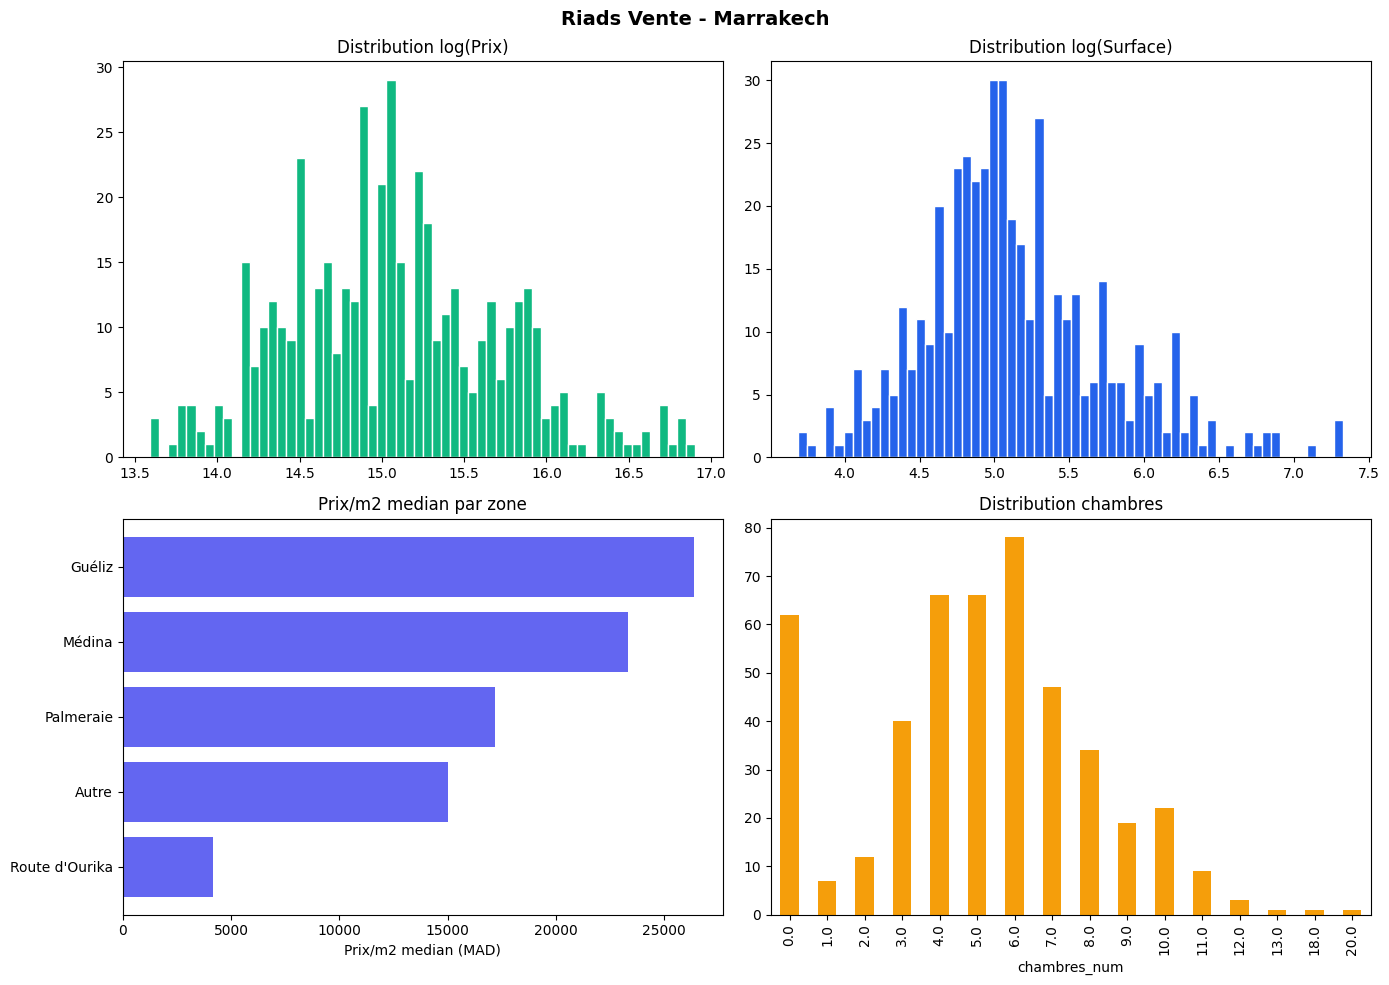

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Riads Vente - Marrakech", fontsize=14, fontweight="bold")

axes[0,0].hist(df["log_prix"], bins=60, color="#10B981", edgecolor="white")
axes[0,0].set_title("Distribution log(Prix)")

axes[0,1].hist(df["log_surface"], bins=60, color="#2563EB", edgecolor="white")
axes[0,1].set_title("Distribution log(Surface)")

med = df.groupby("zone_clean")["prix_m2"].median().sort_values()
axes[1,0].barh(med.index, med.values, color="#6366F1")
axes[1,0].set_xlabel("Prix/m2 median (MAD)")
axes[1,0].set_title("Prix/m2 median par zone")

df["chambres_num"].value_counts().sort_index().plot(kind="bar", ax=axes[1,1], color="#F59E0B")
axes[1,1].set_title("Distribution chambres")
plt.tight_layout(); plt.show()

In [4]:
print("=== Prix median par zone ===")
print(df.groupby("zone_clean")["prix_m2"]
      .agg(["median","count"]).sort_values("median", ascending=False).round(0))

print("\n=== Variance log_prix par zone ===")
print(df.groupby("zone_clean")["log_prix"]
      .agg(["mean","std","count"]).sort_values("std", ascending=False).round(3))

print("\n=== Correlation features -> log_prix ===")
num_check = ["surface_num","log_surface","chambres_num","salles_bain_num",
             "nb_pieces","score_standing","score_confort","piscine",
             "surf_x_piscine","surf_x_ch"]
avail = [c for c in num_check if c in df.columns]
print(df[avail+["log_prix"]].corr()["log_prix"].drop("log_prix")
      .sort_values(ascending=False).round(3))

=== Prix median par zone ===
                 median  count
zone_clean                    
Guéliz          26392.0      4
Médina          23339.0    351
Palmeraie       17188.0      6
Autre           15000.0     96
Route d'Ourika   4143.0     11

=== Variance log_prix par zone ===
                  mean    std  count
zone_clean                          
Route d'Ourika  14.502  0.727     11
Autre           14.917  0.676     96
Médina          15.138  0.626    351
Guéliz          15.933  0.583      4
Palmeraie       14.835  0.471      6

=== Correlation features -> log_prix ===
log_surface        0.575
surface_num        0.493
nb_pieces          0.436
surf_x_ch          0.427
salles_bain_num    0.398
chambres_num       0.286
score_standing     0.154
score_confort      0.140
piscine            0.136
Name: log_prix, dtype: float64


## 2. Split et Feature Engineering

In [5]:
X_train, X_test, y_train, y_test, df_train, df_test, stats = split_and_encode(
    df, test_size=0.2, random_state=42
)
print(f"Features total : {X_train.shape[1]}")
print(f"  NUMERIC : {len(stats['numeric_cols'])}")
print(f"  CATEG   : {len(stats['categorical_cols'])}")

Features total : 47
  NUMERIC : 43
  CATEG   : 4


## 3. Baseline

In [6]:
pipeline_baseline = build_pipeline(stats)
pipeline_baseline = train(pipeline_baseline, X_train, y_train)
metrics_baseline  = evaluate(pipeline_baseline, X_test, y_test, df_test,
                              X_train=X_train, y_train=y_train)

 Entraînement...

═════════════════════════════════════════════
  MÉTRIQUES — RIAD VENTE
═════════════════════════════════════════════
  MAE              :         839,713 MAD
  RMSE             :       1,800,624 MAD
  R²               :          0.8838
  MAPE             :           16.89 %
  CV R² (5 folds)  : 0.8694 ± 0.0268
═════════════════════════════════════════════


## 4. Tuning Optuna

In [7]:
best_params, study = tune_hyperparams(X_train, y_train, stats, n_trials=150)

 Optuna 150 trials sur X_train (CV 5-fold)...


Best trial: 102. Best value: 0.882005: 100%|██████████| 150/150 [00:41<00:00,  3.64it/s]

 Meilleur R² CV : 0.8820
   n_estimators                  : 674
   max_depth                     : 5
   learning_rate                 : 0.06396936513641446
   max_leaves                    : 26
   subsample                     : 0.7862860963109304
   colsample_bytree              : 0.9739400114170255
   colsample_bylevel             : 0.9498783697957359
   min_child_weight              : 7
   reg_alpha                     : 0.009905892033945866
   reg_lambda                    : 0.22568807724262102
   gamma                         : 0.17650495973030328


In [8]:
pipeline_final = build_pipeline(stats, best_params)
pipeline_final = train(pipeline_final, X_train, y_train)
metrics_final  = evaluate(pipeline_final, X_test, y_test, df_test,
                           X_train=X_train, y_train=y_train)

r2_base = metrics_baseline["R²"]
r2_fin  = metrics_final["R²"]
mape_b  = metrics_baseline["MAPE (%)"]
mape_f  = metrics_final["MAPE (%)"]
print(f"\n=== Gain vs baseline ===")
print(f"  R2   : {r2_base:.4f} -> {r2_fin:.4f}  ({r2_fin - r2_base:+.4f})")
print(f"  MAPE : {mape_b:.2f}% -> {mape_f:.2f}%")

 Entraînement...

═════════════════════════════════════════════
  MÉTRIQUES — RIAD VENTE
═════════════════════════════════════════════
  MAE              :         864,829 MAD
  RMSE             :       1,720,827 MAD
  R²               :          0.8882
  MAPE             :           17.45 %
  CV R² (5 folds)  : 0.8766 ± 0.0280
═════════════════════════════════════════════

=== Gain vs baseline ===
  R2   : 0.8838 -> 0.8882  (+0.0044)
  MAPE : 16.89% -> 17.45%


## 5. Analyse erreurs

In [9]:
y_pred_log = pipeline_final.predict(X_test)
prix_pred  = np.exp(y_pred_log)
prix_reel  = df_test["prix_num"].values
erreur_pct = np.abs(prix_pred - prix_reel) / prix_reel * 100

df_err = X_test.copy()
df_err["erreur_pct"]  = erreur_pct
df_err["prix_reel"]   = prix_reel
df_err["prix_predit"] = prix_pred
df_err["surface"]     = df_test["surface_num"].values

print("=== MAPE par zone ===")
print(df_err.groupby("zone_clean")["erreur_pct"]
      .agg(["mean","count"]).sort_values("mean", ascending=False).round(1))

print("\n=== MAPE par segment_prix ===")
print(df_err.groupby("segment_prix")["erreur_pct"]
      .agg(["mean","count"]).sort_values("mean", ascending=False).round(1))

print("\n=== MAPE par cat_surface ===")
print(df_err.groupby("cat_surface")["erreur_pct"]
      .agg(["mean","count"]).sort_values("mean", ascending=False).round(1))

print("\n=== Top 10 pires predictions ===")
print(df_err.nlargest(10,"erreur_pct")[
    ["surface","zone_clean","segment_prix","prix_reel","prix_predit","erreur_pct"]
].to_string())

=== MAPE par zone ===
                mean  count
zone_clean                 
Route d'Ourika  21.5      2
Médina          17.7     70
Autre           16.8     21
Guéliz           8.9      1

=== MAPE par segment_prix ===
              mean  count
segment_prix             
premium       19.9     43
ultra         18.5     10
mid           15.3     35
eco           10.4      6

=== MAPE par cat_surface ===
             mean  count
cat_surface             
estate       22.7      7
large        20.2     13
medium       17.2     23
small        16.3     43
tiny         15.2      8

=== Top 10 pires predictions ===
     surface zone_clean segment_prix   prix_reel  prix_predit  erreur_pct
248    285.0     Médina      premium   3400000.0   5492385.00   61.540735
462    526.0     Médina        ultra  20790000.0  10686564.00   48.597576
463    450.0     Médina        ultra  21978000.0  12108724.00   44.905251
70     360.0     Médina      premium   4000000.0   5686372.50   42.159312
124    216.0  

## 6. Graphiques

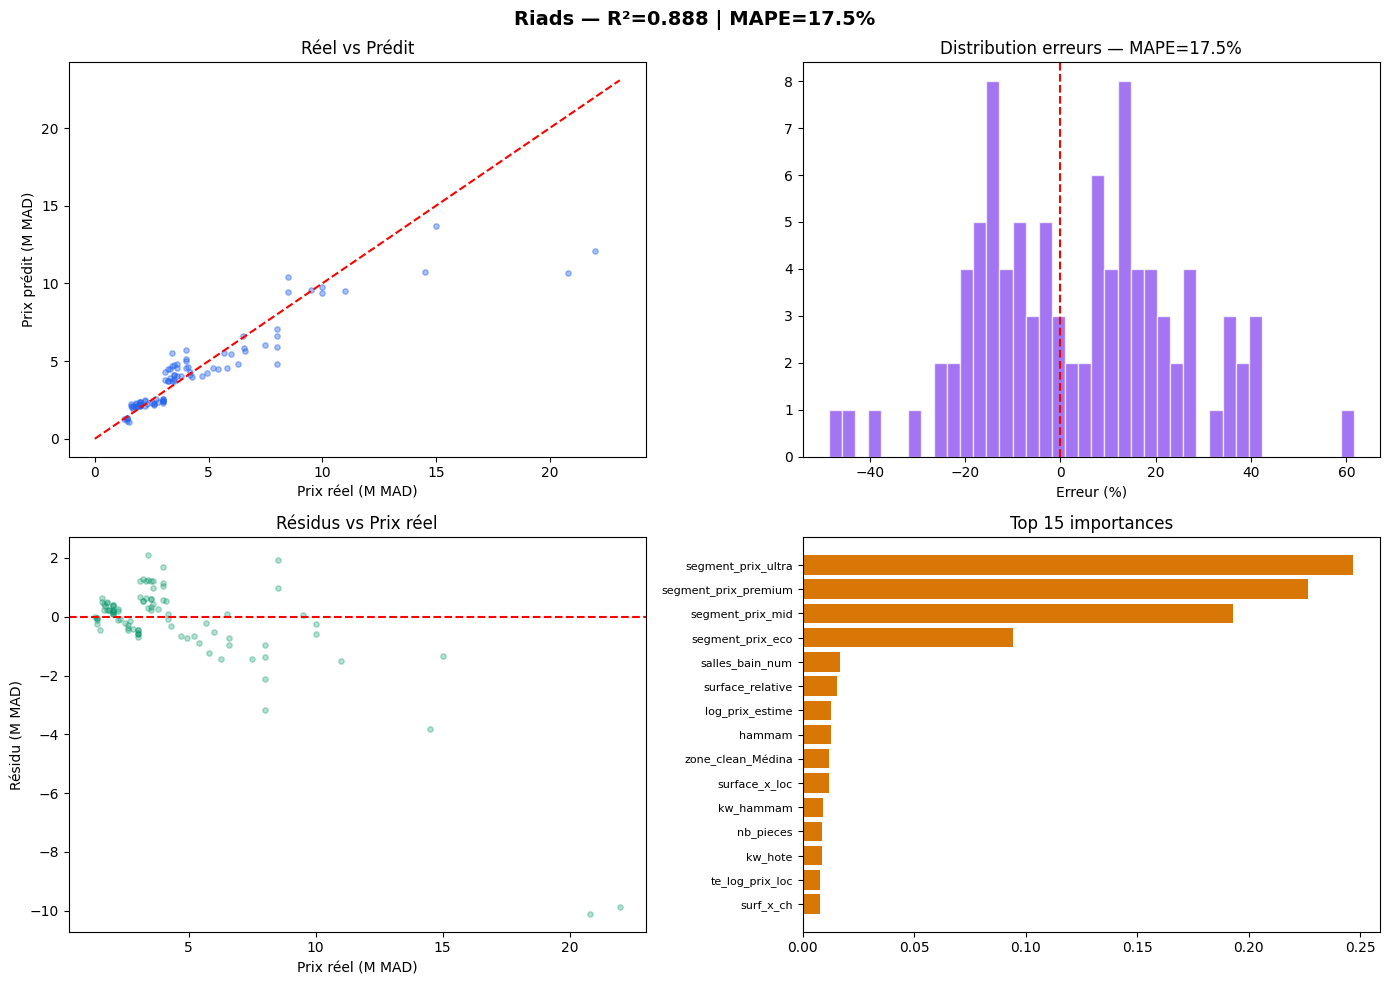

In [10]:
plot_results(pipeline_final, X_test, df_test, metrics_final)

## 7. Sauvegarde

In [11]:
os.makedirs(os.path.dirname(MODEL_PATH), exist_ok=True)
os.makedirs(os.path.dirname(CLEAN_PATH), exist_ok=True)

joblib.dump({"pipeline": pipeline_final, "stats": stats}, MODEL_PATH)
print(f"Modele sauvegarde -> {MODEL_PATH}")

r2_val   = round(float(metrics_final["R²"]), 4)
mape_val = round(float(metrics_final["MAPE (%)"]), 2)
mae_val  = round(float(metrics_final["MAE (MAD)"]), 0)
rmse_val = round(float(metrics_final["RMSE (MAD)"]), 0)
r2_base  = round(float(metrics_baseline["R²"]), 4)
mb_mape  = round(float(metrics_baseline["MAPE (%)"]), 2)

metadata = {
    "date"            : datetime.now().strftime("%Y-%m-%d"),
    "version"         : "v1_optuna",
    "modele"          : "XGBRegressor",
    "type_bien"       : "riad_vente",
    "target"          : "log(prix_total)",
    "n_lignes_train"  : len(X_train),
    "n_lignes_test"   : len(X_test),
    "n_features"      : X_train.shape[1],
    "n_zones"         : int(df["zone_clean"].nunique()),
    "metriques_baseline": {"R2": r2_base, "MAPE": mb_mape},
    "metriques_test"  : {"R2": r2_val, "MAE": mae_val, "RMSE": rmse_val, "MAPE": mape_val},
    "cv_r2_optuna"    : round(study.best_value, 4),
    "hyperparametres" : study.best_params,
}
with open(META_PATH, "w", encoding="utf-8") as f:
    json.dump(metadata, f, ensure_ascii=False, indent=2)

df.to_csv(CLEAN_PATH, index=False)

print(f"\n" + "="*50)
print("  RESUME FINAL - RIAD VENTE")
print("="*50)
print(f"  Donnees  : {len(df):,} riads | {df['zone_clean'].nunique()} zones")
print(f"  R2 final : {r2_val}")
print(f"  MAE      : {mae_val:,.0f} MAD")
print(f"  MAPE     : {mape_val} %")
print(f"  CV R2    : {study.best_value:.4f}")
print("="*50)

Modele sauvegarde -> ../../model_training/models/xgb_riad_vente.pkl

  RESUME FINAL - RIAD VENTE
  Donnees  : 468 riads | 5 zones
  R2 final : 0.8882
  MAE      : 864,829 MAD
  MAPE     : 17.45 %
  CV R2    : 0.8820


## 8. Prediction unitaire

In [12]:
saved           = joblib.load(MODEL_PATH)
pipeline_loaded = saved["pipeline"]
stats_loaded    = saved["stats"]

riad_exemple = {
    "surface_num"      : 150,
    "zone_clean"       : "M'hamid",
    "localisation_fine": "mhamid",
    "chambres_num"     : 4,
    "salles_bain_num"  : 2,
    "piscine"          : 0,
    "parking"          : 1,
    "terrasse"         : 1,
    "jardin"           : 1,
    "climatisation"    : 0,
    "titre"            : "Beau riad moderne M'hamid jardin parking",
}

result   = predict_price(pipeline_loaded, riad_exemple, stats_loaded)
prix_min = result["prix_point"] * 0.75
prix_max = result["prix_point"] * 1.25
print(f"  Fourchette : {prix_min:,.0f} - {prix_max:,.0f} MAD")


 Riad — 150 m² | M'hamid
   Prix estimé : 4,147,000 MAD
   Prix/m²     : 27,600 MAD/m²
  Fourchette : 3,110,366 - 5,183,944 MAD
